In [1]:
import duckdb
import os

PARQUET_DIR = os.path.expanduser('~/kkbox-churn/data/parquet/')
con = duckdb.connect()

# Transaction date ranges
print("=== TRANSACTIONS DATE RANGE ===")
txn_dates = con.execute(f"""
    SELECT 
        MIN(transaction_date) AS min_date,
        MAX(transaction_date) AS max_date
    FROM (
        SELECT transaction_date FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT transaction_date FROM '{PARQUET_DIR}transactions_v2.parquet'
    )
""").df()
print(txn_dates)

# User logs date ranges
print("\n=== USER LOGS DATE RANGE ===")
log_dates = con.execute(f"""
    SELECT 
        MIN(date) AS min_date,
        MAX(date) AS max_date
    FROM '{PARQUET_DIR}user_logs.parquet'
""").df()
print(log_dates)

# User logs v2 date ranges
print("\n=== USER LOGS V2 DATE RANGE ===")
log_v2_dates = con.execute(f"""
    SELECT 
        MIN(date) AS min_date,
        MAX(date) AS max_date
    FROM '{PARQUET_DIR}user_logs_v2.parquet'
""").df()
print(log_v2_dates)

con.close()

=== TRANSACTIONS DATE RANGE ===
   min_date  max_date
0  20150101  20170331

=== USER LOGS DATE RANGE ===
   min_date  max_date
0  20150101  20170228

=== USER LOGS V2 DATE RANGE ===
   min_date  max_date
0  20170301  20170331


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PARQUET_DIR = os.path.expanduser('~/kkbox-churn/data/parquet/')
con = duckdb.connect()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Ready.")

Ready.


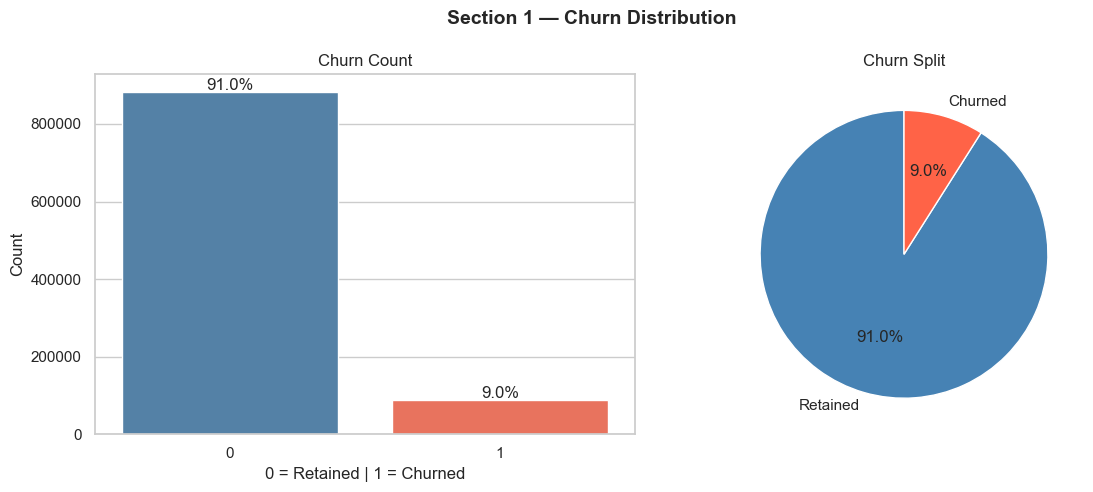

   is_churn   count        pct
0         0  883630  91.005809
1         1   87330   8.994191


In [3]:
churn = con.execute(f"""
    SELECT 
        is_churn,
        COUNT(*) AS count
    FROM '{PARQUET_DIR}train_v2.parquet'
    GROUP BY is_churn
""").df()

churn['pct'] = churn['count'] / churn['count'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.barplot(data=churn, x='is_churn', y='count',
            palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('0 = Retained | 1 = Churned')
axes[0].set_ylabel('Count')
for i, row in churn.iterrows():
    axes[0].text(i, row['count'] + 5000,
                 f"{row['pct']:.1f}%", ha='center', fontsize=12)

# Pie chart
axes[1].pie(churn['count'], labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Churn Split')

plt.suptitle('Section 1 — Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(churn)

    city  total_users  churned  churn_rate
0      1       442598  28351.0    0.064056
1   <NA>       109993   5882.0    0.053476
2     13        97136  11950.0    0.123023
3      5        70706   9333.0    0.131997
4      4        47227   6094.0    0.129036
5     15        43187   5538.0    0.128233
6     22        41991   5284.0    0.125836
7      6        26066   3358.0    0.128827
8     14        20013   2370.0    0.118423
9     12        11383   1585.0    0.139243
10     9         9526   1200.0    0.125971
11    11         9138   1096.0    0.119939
12    18         7792    913.0    0.117171
13     8         7589   1021.0    0.134537
14    10         6470    858.0    0.132612
15    17         5476    571.0    0.104273
16    21         5199    765.0    0.147144
17     3         5057    672.0    0.132885
18     7         2652    296.0    0.111614
19    16          944    104.0    0.110169
20    20          677     72.0    0.106352
21    19          140     17.0    0.121429


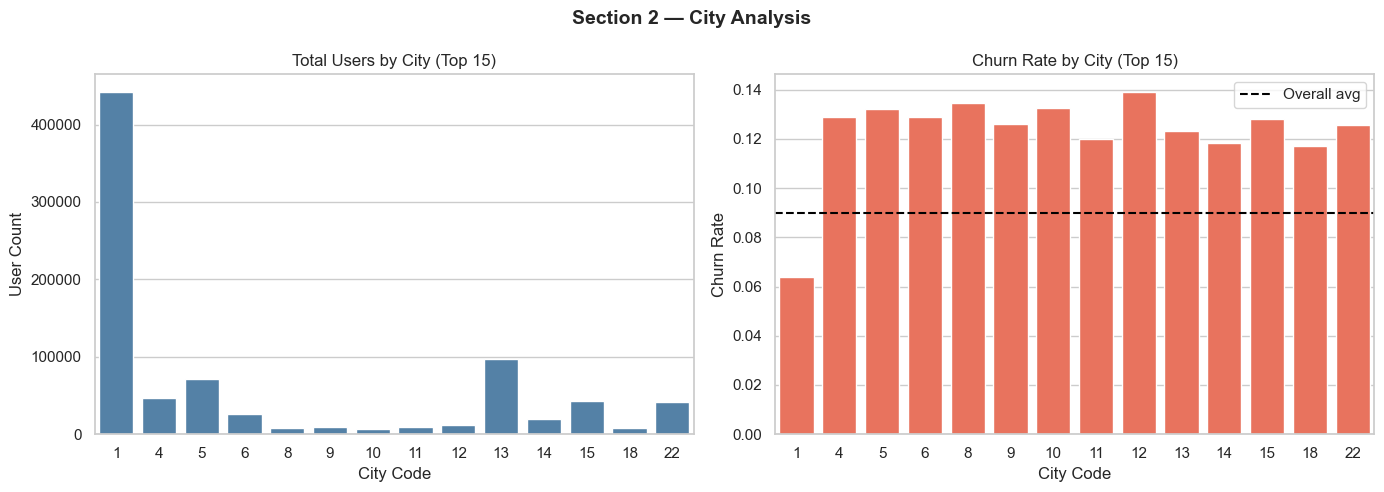

In [4]:
city_churn = con.execute(f"""
    SELECT 
        m.city,
        COUNT(*) AS total_users,
        SUM(t.is_churn) AS churned,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    GROUP BY m.city
    ORDER BY total_users DESC
""").df()

print(city_churn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total users per city
sns.barplot(data=city_churn.head(15), x='city', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Total Users by City (Top 15)')
axes[0].set_xlabel('City Code')
axes[0].set_ylabel('User Count')

# Churn rate per city
sns.barplot(data=city_churn.head(15), x='city', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by City (Top 15)')
axes[1].set_xlabel('City Code')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black', linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 2 — City Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

    gender  total_users  churned  churn_rate
0  unknown       582055  36994.0    0.063558
1     male       204561  26396.0    0.129037
2   female       184344  23940.0    0.129866


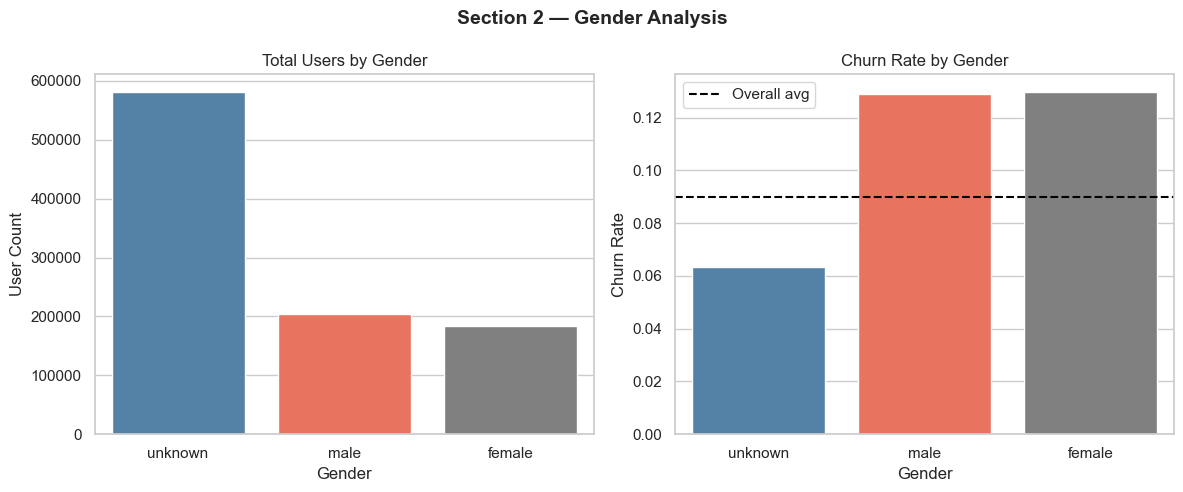

In [5]:
gender_churn = con.execute(f"""
    SELECT 
        COALESCE(m.gender, 'unknown') AS gender,
        COUNT(*) AS total_users,
        SUM(t.is_churn) AS churned,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    GROUP BY m.gender
    ORDER BY total_users DESC
""").df()

print(gender_churn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=gender_churn, x='gender', y='total_users',
            palette=['steelblue', 'tomato', 'gray'], ax=axes[0])
axes[0].set_title('Total Users by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('User Count')

sns.barplot(data=gender_churn, x='gender', y='churn_rate',
            palette=['steelblue', 'tomato', 'gray'], ax=axes[1])
axes[1].set_title('Churn Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black', linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 2 — Gender Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

   registered_via  total_users  churned  churn_rate
0               7       462684  20697.0    0.044732
1               9       235689  29893.0    0.126832
2            <NA>       109993   5882.0    0.053476
3               3       106459  18338.0    0.172254
4               4        52744  12185.0    0.231022
5              13         3391    335.0    0.098791


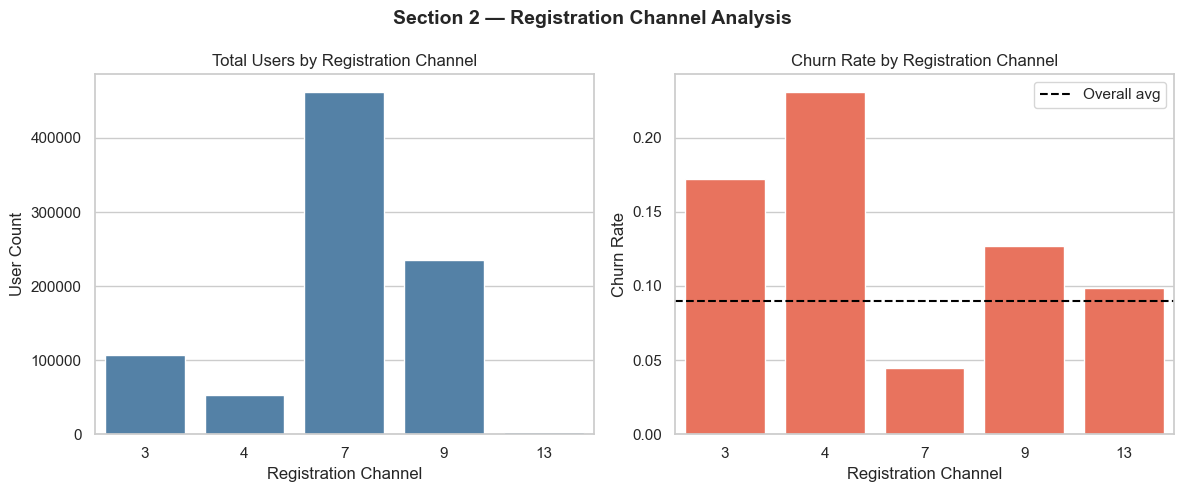

In [6]:
reg_churn = con.execute(f"""
    SELECT 
        m.registered_via,
        COUNT(*) AS total_users,
        SUM(t.is_churn) AS churned,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    GROUP BY m.registered_via
    ORDER BY total_users DESC
""").df()

print(reg_churn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=reg_churn, x='registered_via', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Total Users by Registration Channel')
axes[0].set_xlabel('Registration Channel')
axes[0].set_ylabel('User Count')

sns.barplot(data=reg_churn, x='registered_via', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Registration Channel')
axes[1].set_xlabel('Registration Channel')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black', 
                linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 2 — Registration Channel Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  age_group  total_users  churned  churn_rate
0  under 18         9587   2701.0    0.281736
1     18-24       104948  19304.0    0.183939
2   invalid          951    135.0    0.141956
3     25-34       177130  19614.0    0.110732
4     35-44        66310   6999.0    0.105550
5     45-54        22122   2074.0    0.093753
6       55+         6190    571.0    0.092246
7   unknown       583722  35932.0    0.061557


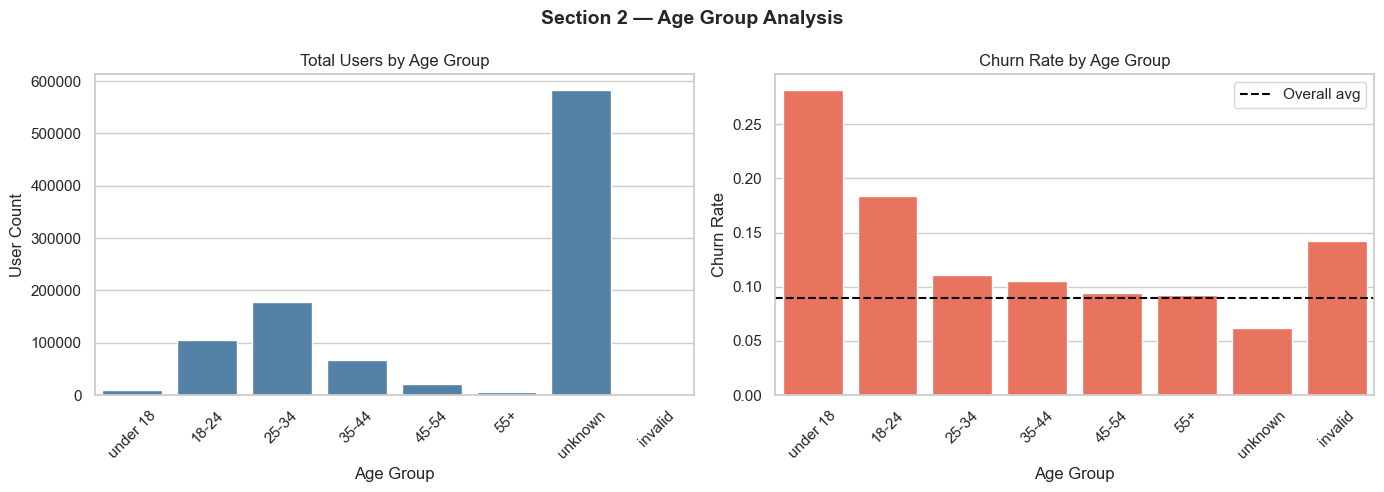

In [7]:
age_churn = con.execute(f"""
    SELECT 
        CASE 
            WHEN bd = 0 OR bd IS NULL THEN 'unknown'
            WHEN bd < 0 OR bd > 80 THEN 'invalid'
            WHEN bd BETWEEN 1 AND 13 THEN 'invalid'
            WHEN bd BETWEEN 14 AND 17 THEN 'under 18'
            WHEN bd BETWEEN 18 AND 24 THEN '18-24'
            WHEN bd BETWEEN 25 AND 34 THEN '25-34'
            WHEN bd BETWEEN 35 AND 44 THEN '35-44'
            WHEN bd BETWEEN 45 AND 54 THEN '45-54'
            WHEN bd > 54 THEN '55+'
        END AS age_group,
        COUNT(*) AS total_users,
        SUM(t.is_churn) AS churned,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    GROUP BY age_group
    ORDER BY churn_rate DESC
""").df()

print(age_churn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['under 18', '18-24', '25-34', '35-44', '45-54', '55+', 'unknown', 'invalid']
age_ordered = age_churn.set_index('age_group').reindex(order).reset_index().dropna()

sns.barplot(data=age_ordered, x='age_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Total Users by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=age_ordered, x='age_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black', linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 2 — Age Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
bd_check = con.execute(f"""
    SELECT 
        bd,
        COUNT(*) as count
    FROM '{PARQUET_DIR}members_v3.parquet'
    WHERE bd BETWEEN 1 AND 15
    GROUP BY bd
    ORDER BY bd ASC
""").df()

print("Ages 1-15:")
print(bd_check)

print("\nTotal bd=0:")
zero = con.execute(f"""
    SELECT COUNT(*) 
    FROM '{PARQUET_DIR}members_v3.parquet'
    WHERE bd = 0
""").fetchone()[0]
print(zero)

print("\nTotal bd < 0:")
negative = con.execute(f"""
    SELECT COUNT(*) 
    FROM '{PARQUET_DIR}members_v3.parquet'
    WHERE bd < 0
""").fetchone()[0]
print(negative)

print("\nTotal bd > 80:")
old = con.execute(f"""
    SELECT COUNT(*) 
    FROM '{PARQUET_DIR}members_v3.parquet'
    WHERE bd > 80
""").fetchone()[0]
print(old)

Ages 1-15:
    bd  count
0    1     67
1    2     37
2    3     53
3    4    108
4    5    122
5    6    170
6    7    148
7    8    113
8    9     81
9   10     97
10  11    106
11  12    199
12  13    790
13  14   5632
14  15  16645

Total bd=0:
4540215

Total bd < 0:
274

Total bd > 80:
9170


In [9]:
# Check if transactions has any age-related info
txn_sample = con.execute(f"""
    SELECT * FROM '{PARQUET_DIR}transactions.parquet'
    LIMIT 3
""").df()
print("TRANSACTIONS columns:", txn_sample.columns.tolist())

# Check members again for any hidden columns
members_sample = con.execute(f"""
    SELECT * FROM '{PARQUET_DIR}members_v3.parquet'
    LIMIT 3
""").df()
print("\nMEMBERS columns:", members_sample.columns.tolist())

# Check user logs
logs_sample = con.execute(f"""
    SELECT * FROM '{PARQUET_DIR}user_logs_v2.parquet'
    LIMIT 3
""").df()
print("\nUSER LOGS columns:", logs_sample.columns.tolist())

TRANSACTIONS columns: ['msno', 'payment_method_id', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'transaction_date', 'membership_expire_date', 'is_cancel']

MEMBERS columns: ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']

USER LOGS columns: ['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']


In [10]:
# How many train_v2 users are in members_v3
members_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT t.msno)                    AS total_train_users,
        COUNT(DISTINCT m.msno)                    AS matched_in_members,
        COUNT(DISTINCT t.msno) - 
        COUNT(DISTINCT m.msno)                    AS missing_from_members
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
""").df()

print("=== MEMBERS COVERAGE ===")
print(members_coverage)

# How many train_v2 users are in user_logs
logs_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT t.msno)                    AS total_train_users,
        COUNT(DISTINCT l.msno)                    AS matched_in_logs,
        COUNT(DISTINCT t.msno) - 
        COUNT(DISTINCT l.msno)                    AS missing_from_logs
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}user_logs_v2.parquet' l
        ON t.msno = l.msno
""").df()

print("\n=== USER LOGS V2 COVERAGE ===")
print(logs_coverage)

# How many train_v2 users are in transactions
txn_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT t.msno)                    AS total_train_users,
        COUNT(DISTINCT tr.msno)                   AS matched_in_transactions,
        COUNT(DISTINCT t.msno) - 
        COUNT(DISTINCT tr.msno)                   AS missing_from_transactions
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}transactions.parquet' tr
        ON t.msno = tr.msno
""").df()

print("\n=== TRANSACTIONS COVERAGE ===")
print(txn_coverage)

=== MEMBERS COVERAGE ===
   total_train_users  matched_in_members  missing_from_members
0             970960              860967                109993

=== USER LOGS V2 COVERAGE ===
   total_train_users  matched_in_logs  missing_from_logs
0             970960           754551             216409

=== TRANSACTIONS COVERAGE ===
   total_train_users  matched_in_transactions  missing_from_transactions
0             970960                   968433                       2527


In [11]:
full_logs_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT t.msno)          AS total_train_users,
        COUNT(DISTINCT l.msno)          AS matched_in_full_logs,
        COUNT(DISTINCT t.msno) - 
        COUNT(DISTINCT l.msno)          AS missing_from_full_logs
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}user_logs.parquet' l
        ON t.msno = l.msno
""").df()

print("=== FULL USER LOGS COVERAGE ===")
print(full_logs_coverage)

=== FULL USER LOGS COVERAGE ===
   total_train_users  matched_in_full_logs  missing_from_full_logs
0             970960                850296                  120664


In [12]:
combined_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT t.msno)      AS total_train_users,
        COUNT(DISTINCT l.msno)      AS matched_in_combined_logs,
        COUNT(DISTINCT t.msno) - 
        COUNT(DISTINCT l.msno)      AS missing_from_combined_logs
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN (
        SELECT msno FROM '{PARQUET_DIR}user_logs.parquet'
        UNION
        SELECT msno FROM '{PARQUET_DIR}user_logs_v2.parquet'
    ) l ON t.msno = l.msno
""").df()

print("=== COMBINED LOGS COVERAGE ===")

print(combined_coverage)

=== COMBINED LOGS COVERAGE ===
   total_train_users  matched_in_combined_logs  missing_from_combined_logs
0             970960                    855160                      115800


In [13]:
no_logs_churn = con.execute(f"""
    SELECT 
        CASE WHEN l.msno IS NULL THEN 'no_history' 
             ELSE 'has_history' END AS log_status,
        COUNT(*) AS total_users,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN (
        SELECT DISTINCT msno FROM '{PARQUET_DIR}user_logs.parquet'
        UNION
        SELECT DISTINCT msno FROM '{PARQUET_DIR}user_logs_v2.parquet'
    ) l ON t.msno = l.msno
    GROUP BY log_status
""").df()


print(no_logs_churn)

    log_status  total_users  churn_rate
0   no_history       115800    0.055268
1  has_history       855160    0.094637


    reg_year  total_users  churn_rate
0       2004         8330    0.087875
1       2005        15616    0.068071
2       2006        18048    0.081394
3       2007        26158    0.090450
4       2008        17685    0.100424
5       2009        15731    0.110864
6       2010        38640    0.116382
7       2011        60698    0.087845
8       2012        74495    0.096221
9       2013       113444    0.101627
10      2014        89332    0.105808
11      2015       154376    0.085616
12      2016       195184    0.088481
13      2017        33230    0.115348
14      <NA>       109993    0.053476


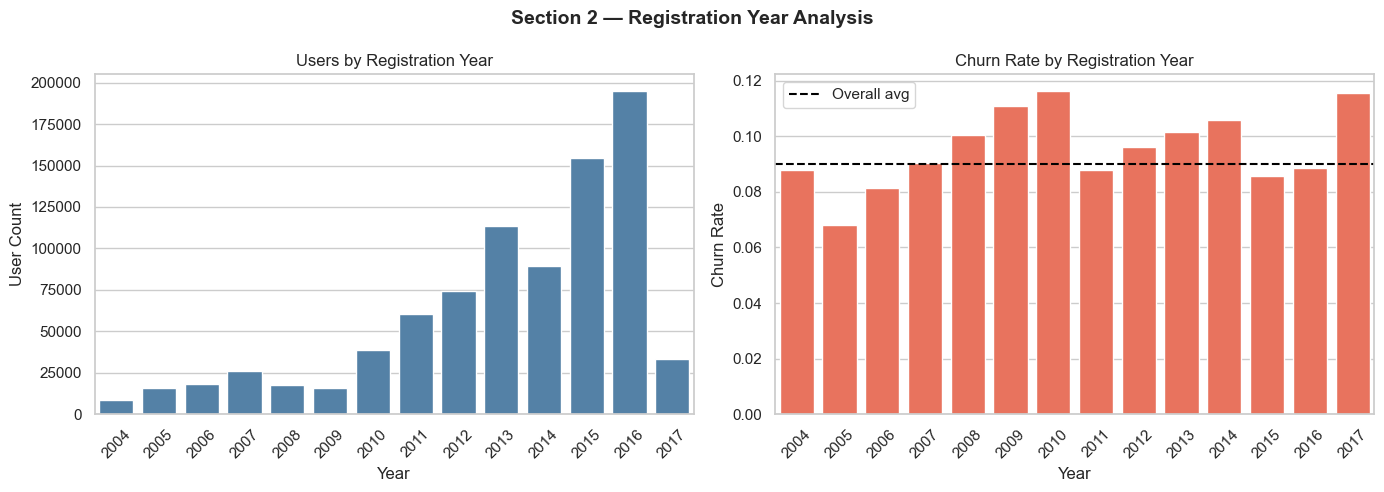

In [14]:
reg_time = con.execute(f"""
    SELECT 
        CAST(SUBSTR(CAST(registration_init_time AS VARCHAR), 1, 4) AS INT) AS reg_year,
        COUNT(*) AS total_users,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    GROUP BY reg_year
    ORDER BY reg_year ASC
""").df()

print(reg_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=reg_time, x='reg_year', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Registration Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=reg_time, x='reg_year', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Registration Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black', linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 2 — Registration Year Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
reg_sample = con.execute(f"""
    SELECT 
        registration_init_time,
        LENGTH(CAST(registration_init_time AS VARCHAR)) AS length,
        COUNT(*) AS count
    FROM '{PARQUET_DIR}members_v3.parquet'
    WHERE registration_init_time > 0
    GROUP BY registration_init_time, length
    ORDER BY count DESC
    LIMIT 10
""").df()

print("=== REGISTRATION INIT TIME SAMPLE ===")
print(reg_sample)

# Min and max
reg_range = con.execute(f"""
    SELECT 
        MIN(registration_init_time) AS min_date,
        MAX(registration_init_time) AS max_date,
        COUNT(*) AS total,
        SUM(CASE WHEN registration_init_time = 0 
            THEN 1 ELSE 0 END) AS zero_count
    FROM '{PARQUET_DIR}members_v3.parquet'
""").df()

print("\n=== REGISTRATION DATE RANGE ===")
print(reg_range)

=== REGISTRATION INIT TIME SAMPLE ===
   registration_init_time  length  count
0                20151009       8  12413
1                20151010       8  11537
2                20151121       8  11143
3                20151107       8  10959
4                20151017       8  10874
5                20151011       8  10547
6                20160124       8  10517
7                20151101       8  10515
8                20151031       8  10352
9                20151108       8  10320

=== REGISTRATION DATE RANGE ===
   min_date  max_date    total  zero_count
0  20040326  20170429  6769473         0.0


     age_bucket  total_users  churn_rate
0       invalid          758    0.631926
1     2-3 years        83045    0.115323
2     3-5 years       188833    0.099967
3     0-90 days        48021    0.098332
4      5+ years       219284    0.093203
5     1-2 years       186784    0.087818
6   91-180 days        39728    0.083744
7  181-365 days        94514    0.080676


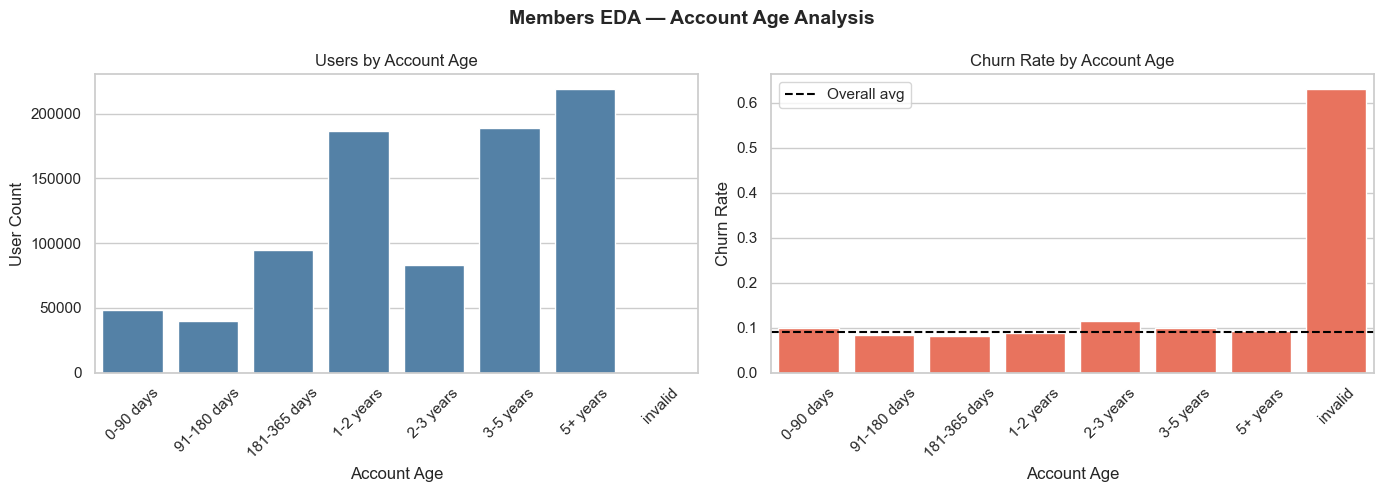

In [17]:
account_age = con.execute(f"""
    WITH user_age AS (
        SELECT
            m.msno,
            DATEDIFF('day',
                STRPTIME(CAST(m.registration_init_time AS VARCHAR), '%Y%m%d'),
                DATE '2017-03-01'
            ) AS account_age_days
        FROM '{PARQUET_DIR}members_v3.parquet' m
    )
    SELECT
        CASE
            WHEN account_age_days < 0     THEN 'invalid'
            WHEN account_age_days <= 90   THEN '0-90 days'
            WHEN account_age_days <= 180  THEN '91-180 days'
            WHEN account_age_days <= 365  THEN '181-365 days'
            WHEN account_age_days <= 730  THEN '1-2 years'
            WHEN account_age_days <= 1095 THEN '2-3 years'
            WHEN account_age_days <= 1825 THEN '3-5 years'
            ELSE '5+ years'
        END AS age_bucket,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_age u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY age_bucket
    ORDER BY churn_rate DESC
""").df()

print(account_age)

order = ['0-90 days', '91-180 days', '181-365 days',
         '1-2 years', '2-3 years', '3-5 years', '5+ years', 'invalid']
age_ordered = account_age.set_index('age_bucket')\
                         .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=age_ordered, x='age_bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Account Age')
axes[0].set_xlabel('Account Age')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=age_ordered, x='age_bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Account Age')
axes[1].set_xlabel('Account Age')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Members EDA — Account Age Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

     gender age_group  total_users  churn_rate
0   unknown  under 25         3412    0.440797
1      male  under 25        59262    0.187743
2   unknown     25-34         3854    0.183446
3    female  under 25        51861    0.180772
4   unknown     35-44         1600    0.169375
5   unknown       45+          686    0.150146
6      male   invalid          513    0.148148
7   unknown   invalid           89    0.146067
8      male   unknown         5138    0.137797
9    female   unknown         6170    0.134198
10   female   invalid          349    0.131805
11   female     25-34        79012    0.113261
12     male     25-34        94264    0.105639
13   female     35-44        32661    0.104406
14     male     35-44        32049    0.103529
15   female       45+        14291    0.093206
16     male       45+        13335    0.090739
17  unknown   unknown       572414    0.060089


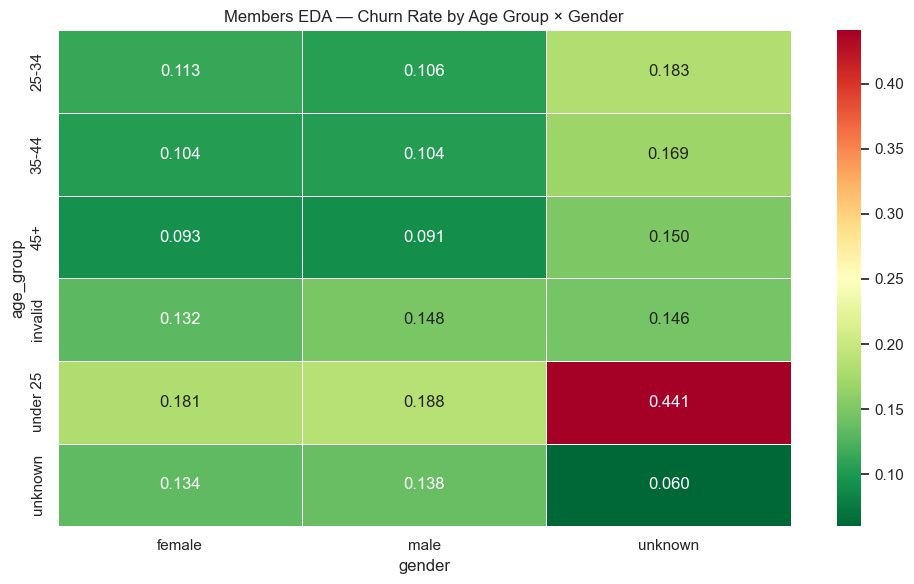

In [18]:
age_gender = con.execute(f"""
    SELECT
        COALESCE(m.gender, 'unknown') AS gender,
        CASE
            WHEN m.bd = 0 OR m.bd IS NULL THEN 'unknown'
            WHEN m.bd < 14 OR m.bd > 80   THEN 'invalid'
            WHEN m.bd BETWEEN 14 AND 24    THEN 'under 25'
            WHEN m.bd BETWEEN 25 AND 34    THEN '25-34'
            WHEN m.bd BETWEEN 35 AND 44    THEN '35-44'
            ELSE '45+'
        END AS age_group,
        COUNT(*) AS total_users,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    GROUP BY gender, age_group
    ORDER BY churn_rate DESC
""").df()

print(age_gender)

# Pivot for heatmap
pivot = age_gender.pivot(index='age_group',
                         columns='gender',
                         values='churn_rate')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f',
            cmap='RdYlGn_r', linewidths=0.5)
plt.title('Members EDA — Churn Rate by Age Group × Gender')
plt.tight_layout()
plt.show()

    city  registered_via  total_users  churn_rate
0      1               9        17304    0.259998
1      1               4        21661    0.258483
2      1               3        12905    0.250678
3      5               4         5540    0.228159
4     14               4         1250    0.216000
5      6               4         2298    0.213229
6     15               4         3340    0.212275
7      4               4         3812    0.211962
8     22               4         3574    0.209569
9     12               3         2479    0.197257
10    13               4         5858    0.195459
11    21               3         1232    0.190747
12     8               3         1670    0.185030
13     3               3         1133    0.181818
14     5               3        15208    0.174645
15    10               3         1464    0.173497
16     9               3         1958    0.169050
17     4               3        10467    0.167097
18    15               3        10366    0.160911


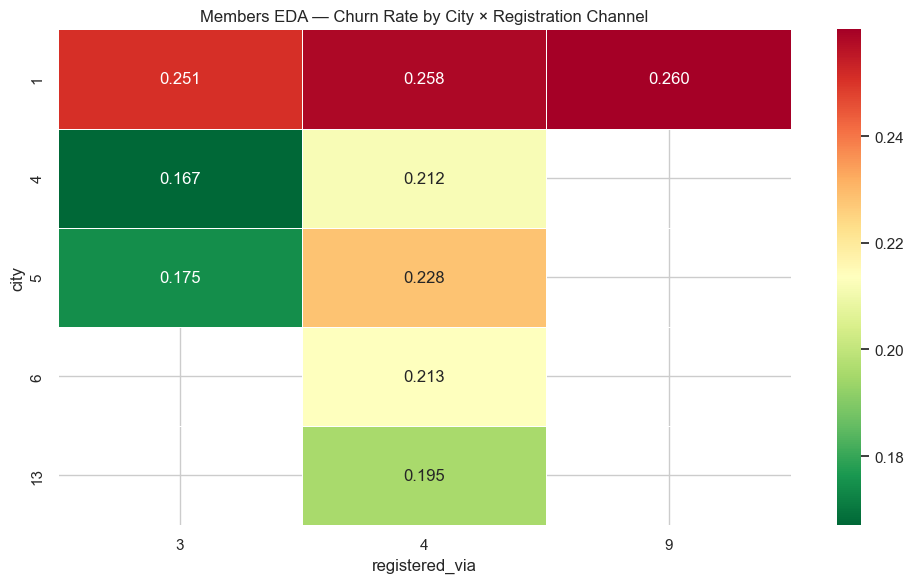

In [20]:
city_channel = con.execute(f"""
    SELECT
        m.city,
        m.registered_via,
        COUNT(*) AS total_users,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN '{PARQUET_DIR}members_v3.parquet' m
        ON t.msno = m.msno
    WHERE m.city IS NOT NULL
    AND m.registered_via IS NOT NULL
    GROUP BY m.city, m.registered_via
    HAVING COUNT(*) > 1000
    ORDER BY churn_rate DESC
    LIMIT 20
""").df()

print(city_channel)

# Pivot for heatmap — top cities only
top_cities = [1, 4, 5, 6, 13]
top_channels = [3, 4, 7, 9]

filtered = city_channel[
    city_channel['city'].isin(top_cities) &
    city_channel['registered_via'].isin(top_channels)
]

if len(filtered) > 0:
    pivot = filtered.pivot(index='city',
                           columns='registered_via',
                           values='churn_rate')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f',
                cmap='RdYlGn_r', linewidths=0.5)
    plt.title('Members EDA — Churn Rate by City × Registration Channel')
    plt.tight_layout()
    plt.show()

In [21]:
members_not_in_train = con.execute(f"""
    SELECT
        COUNT(DISTINCT m.msno) AS total_members,
        COUNT(DISTINCT t.msno) AS members_in_train,
        COUNT(DISTINCT m.msno) - 
            COUNT(DISTINCT t.msno) AS members_not_in_train
    FROM '{PARQUET_DIR}members_v3.parquet' m
    LEFT JOIN '{PARQUET_DIR}train_v2.parquet' t
        ON m.msno = t.msno
""").df()

print("=== MEMBERS NOT IN TRAIN_V2 ===")
print(members_not_in_train)

# What do these users look like
members_outside = con.execute(f"""
    SELECT
        COALESCE(m.gender, 'unknown') AS gender,
        CASE
            WHEN m.bd = 0 THEN 'unknown'
            WHEN m.bd < 14 OR m.bd > 80 THEN 'invalid'
            WHEN m.bd BETWEEN 14 AND 24 THEN 'under 25'
            WHEN m.bd BETWEEN 25 AND 34 THEN '25-34'
            WHEN m.bd BETWEEN 35 AND 44 THEN '35-44'
            ELSE '45+'
        END AS age_group,
        COUNT(*) AS count
    FROM '{PARQUET_DIR}members_v3.parquet' m
    LEFT JOIN '{PARQUET_DIR}train_v2.parquet' t
        ON m.msno = t.msno
    WHERE t.msno IS NULL
    GROUP BY gender, age_group
    ORDER BY count DESC
    LIMIT 15
""").df()

print("\n=== PROFILE OF MEMBERS NOT IN TRAIN_V2 ===")
print(members_outside)

=== MEMBERS NOT IN TRAIN_V2 ===
   total_members  members_in_train  members_not_in_train
0        6769473            860967               5908506

=== PROFILE OF MEMBERS NOT IN TRAIN_V2 ===
     gender age_group    count
0   unknown   unknown  3926192
1      male  under 25   368044
2    female  under 25   367258
3      male     25-34   297251
4    female     25-34   276479
5      male     35-44   157787
6    female     35-44   157343
7      male       45+    94379
8    female       45+    81986
9    female   unknown    72633
10     male   unknown    67661
11  unknown     25-34    12492
12  unknown  under 25    11340
13     male   invalid     5672
14  unknown     35-44     5210
